In [26]:
import yfinance as yf
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

In [24]:
'''

EACH STRATEGY SHOULD FOLLOW THE FOLLOWING THREE STEPS

1) ACQUIRE THE DATA - SPY

2) DEFINE THE STRATEGY - GOLDEN CROSSOVER

3) TEST THE STRATEGY


'''

'\n\nEACH STRATEGY SHOULD FOLLOW THE FOLLOWING THREE STEPS\n\n1) ACQUIRE THE DATA - SPY\n\n2) DEFINE THE STRATEGY - GOLDEN CROSSOVER\n\n3) TEST THE STRATEGY\n\n\n'

In [ ]:
''' 

ENTRY SIGNAL: 50 DAY MA MOVES ABOVE THE 200 DAY MA

EXIT SIGNAL:  50 DAY MA MOVES BELOW THE 200 DAY MA / PRICE DIPS BELOW THE 200 DAY MA

'''

' \n\nENTRY SIGNAL: 50 DAY MA MOVES ABOVE THE 200 DAY MA\n\nEXIT SIGNAL:  50 DAY MA MOVES BELOW THE DAY DAY/ PRICE DIPS BELOW THE 200 DAY MA\n\n'

In [36]:
# Define global variables
TICKER = "SPY"
FAST = 50
SLOW = 200
LOOKBACK = 500

ACQUIRE & PLOT DATA

In [17]:
def load_data(TICKER):
    data = yf.download(TICKER, period="max")
    data.columns = data.columns.get_level_values(0)
    return pd.DataFrame(data)

In [18]:
df = load_data(TICKER)

[*********************100%***********************]  1 of 1 completed


In [19]:
def add_moving_averages(df):
    df[f"{FAST}"] = df["Close"].rolling(window=SLOW).mean()
    df[f"{SLOW}"] = df["Close"].rolling(window=FAST).mean()
    df = df.dropna()
    return df 

In [20]:
add_moving_averages(df)

Price,Close,High,Low,Open,Volume,50,200
Date,,,,,,,
1993-11-11,25.979630,26.119681,25.962123,26.049655,88900,25.095356,25.888376
1993-11-12,26.102175,26.189707,26.014642,26.032149,108200,25.104990,25.894393
1993-11-15,26.084665,26.154691,26.014639,26.154691,243300,25.113677,25.899711
1993-11-16,26.207199,26.224706,26.032134,26.137173,492600,25.122718,25.910960
1993-11-17,26.067160,26.224718,25.997134,26.224718,39600,25.129770,25.921147
...,...,...,...,...,...,...,...
2026-05-04,718.010010,722.119995,714.989990,720.070007,51950600,668.413918,680.087032
2026-05-05,723.770020,725.039978,721.489990,721.770020,36933200,668.921260,680.951803
2026-05-06,733.830017,734.590027,727.820007,728.159973,53288900,669.473003,681.918845


In [21]:
#plot our moving averages with close price
def plot_dataset(df):
    plt.plot(df["Close"], label="Close Price")
    plt.plot(df[f"{FAST}"], label="50 day moving average")
    plt.plot(df[f"{SLOW}"], label="200 day moving average")
    plt.title(f"{TICKER} Closing Price & 50 & 200 Day Moving Averages")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.legend(loc=2)
    plt.grid(True)
    plt.show()

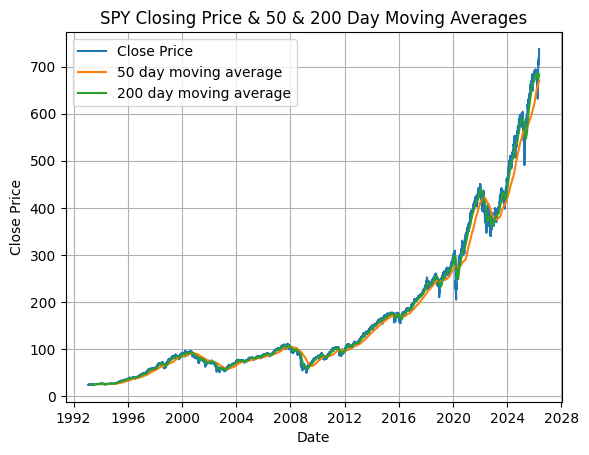

In [22]:
plot_dataset(df)

In [43]:
# Plot a subsection of the past 500 days using the global 'LOOKBACK' variable
def dataset_subset_plot(df):
    subset = df.iloc[-LOOKBACK:, :]
    
    plt.plot(subset["Close"], label="SPY Closing Price")
    plt.plot(subset[f"{SLOW}"], label="50 Day Moving Average")
    plt.plot(subset[f"{FAST}"], label="200 Day Moving Average")
    plt.title("Moving Average Crossovers")
    plt.xlabel("Date")
    plt.ylabel("Closing Price in USD$")
    plt.legend(loc=2)
    plt.grid(True)
    plt.show()

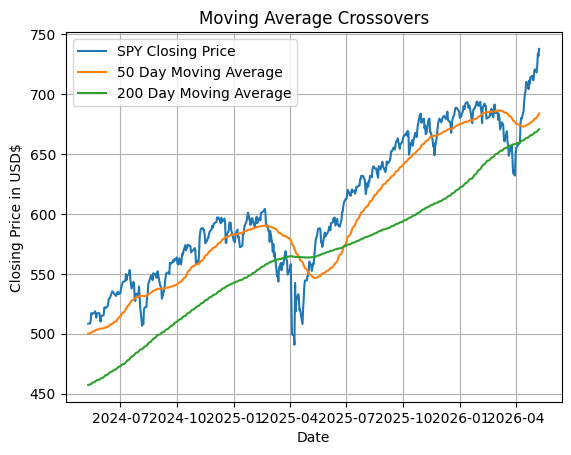

In [44]:
dataset_subset_plot(df)

DEFINE STRATEGY

In [ ]:
'''

LONG POSITION: 50 DAY MOVING AVERAGE > 200 DAY MOVING AVERAGE

SHORT POSITION: 50 DAY MOVING AVERAGE < 200 DAY MOVING AVERAGE 

'''

In [ ]:
def add_strategy(df, SLOW, FAST)
    df["Strategy"] = np.where(df[f"{SLOW}"] > df[f"{FAST}"], -1, 1).shift(1)
    return df

TEST STRATEGY

In [45]:
def test_strategy(df, FAST, SLOW):
    pass